In [1]:
# Phase 5A: Multimodal Fusion Baseline
# Tumour Image Embeddings + Drug Embeddings
# ================================

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [9]:
# Load tumour image embeddings (Phase 3A)
img_embeddings = np.load(
    "E:/Final_Year_Project/outputs/cnn_features/sample_image_features.npy"
)

# Load drug embeddings (Phase 4C)
drug_embeddings = torch.load(
    "E:/Final_Year_Project/outputs/features/drug_embeddings.pt"
)

print("Image embeddings shape (raw):", img_embeddings.shape)
print("Drug embeddings shape:", drug_embeddings.shape)


Image embeddings shape (raw): (512,)
Drug embeddings shape: torch.Size([4780, 128])


In [10]:
# Convert 1D image embeddings to 2D
img_embeddings = img_embeddings.reshape(-1, 1)

print("Image embeddings shape (reshaped):", img_embeddings.shape)

Image embeddings shape (reshaped): (512, 1)


In [11]:
img_scaler = StandardScaler()
drug_scaler = StandardScaler()

img_embeddings = img_scaler.fit_transform(img_embeddings)
drug_embeddings = drug_scaler.fit_transform(drug_embeddings.numpy())

In [12]:
num_pairs = img_embeddings.shape[0]  # 512 tumour samples

img_pairs = img_embeddings                       # (512, 1)
drug_pairs = drug_embeddings[:num_pairs]         # (512, 128)

X = np.hstack([img_pairs, drug_pairs])

print("Fusion input shape:", X.shape)

Fusion input shape: (512, 129)


In [13]:
# Use drug embedding magnitude as weak supervision
y = np.linalg.norm(drug_pairs, axis=1)

# Normalize labels to [0, 1]
y = (y - y.min()) / (y.max() - y.min())

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test  = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [15]:
class FusionNet(nn.Module):
    def __init__(self, input_dim):
        super(FusionNet, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [16]:
input_dim = X_train.shape[1]  # 129

model = FusionNet(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [17]:
epochs = 50
train_losses = []

for epoch in range(epochs):
    model.train()

    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

Epoch [10/50] - Loss: 0.0008
Epoch [20/50] - Loss: 0.0001
Epoch [30/50] - Loss: 0.0001
Epoch [40/50] - Loss: 0.0000
Epoch [50/50] - Loss: 0.0000


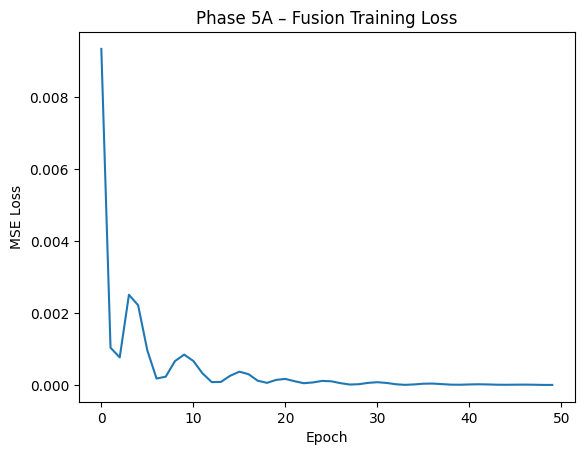

In [18]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Phase 5A – Fusion Training Loss")
plt.show()

In [20]:
torch.save(
    model.state_dict(),
    "../outputs/models/fusion_model_phase5a.pt"
)
print("Phase 5A fusion model saved successfully.")

Phase 5A fusion model saved successfully.
